En este codigo se aplica la funcion nativa de numpy de la transformada rapida de fourier (np.fft.fft), haciendo uso de una funcion compuesta por dos componente sinosuidales con diferentes frecuencias sin(2π4t)+0.8sin(2π7t) (f1 = 4, f2 = 7)

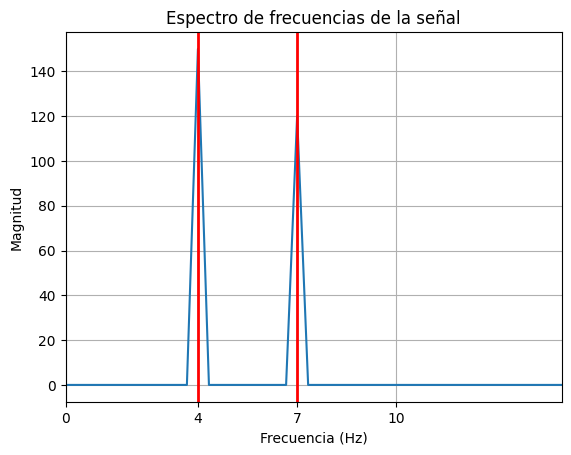

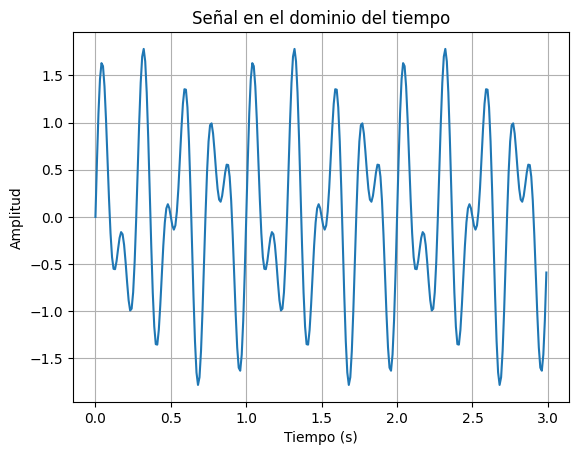

In [16]:
import numpy as np
import matplotlib.pyplot as plt

## La funcion elegida para la comparacion es x(t) = sin(2π4t)+0.8sin(2π7t)

## Parametros

fs = 100 ## frecuencia de muestreo
N = 300 ## numero de muestras tomadas
t = np.arange(N) / fs ## t = 0, 0.1, 0.2...

x = np.sin(2*np.pi*4*t) + 0.8*np.sin(2*np.pi*7*t) ## funcion elegida

fourierX = np.fft.fft(x) ## aplicamos la funcion de la transformada de fourier a nuestra funcion
frecuencias = np.fft.fftfreq(N, d=1/fs) ## usamos esta variable para graficas cuales son las frecuencias presentes en la curva

## graficamos que frecuencias estan presentes
## se grafica unicamente la mitad positiva del espectro,
## ya que la señal es real y la otra mitad es simetrica.

plt.title("Espectro de frecuencias de la señal")
plt.plot(frecuencias[:N//2], np.abs(fourierX[:N//2]))
plt.xticks([0, 4, 7, 10, 20, 30, 40, 50])
plt.axvline(x=4, color='red', linewidth=2)
plt.axvline(x=7, color='red', linewidth=2)
plt.xlim(0, 15)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.grid()
plt.show()

## graficamos la curva obtenida

plt.title("Señal en el dominio del tiempo")
plt.plot(t, x)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

Ahora veamos como se comportan las graficas haciendo uso de DFT en C

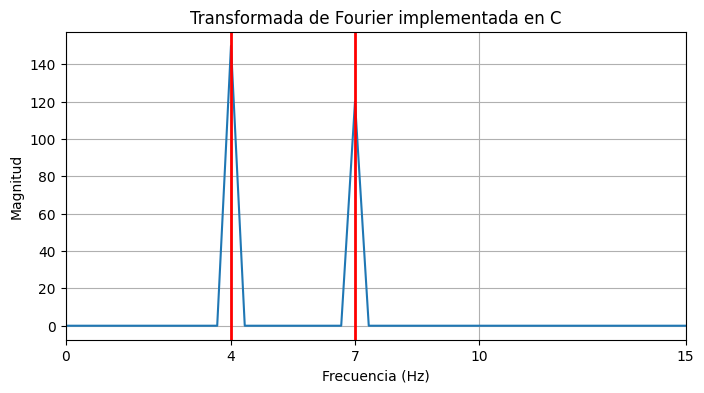

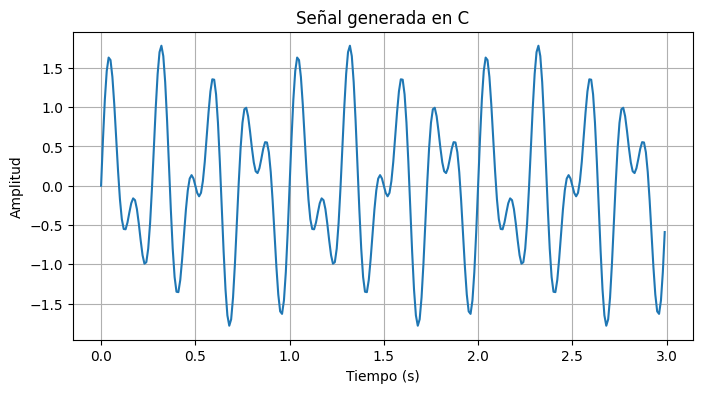

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Lectura de los archivos generados en C

senal = pd.read_csv("senal.csv")
espectro = pd.read_csv("espectro.csv")

# Gráfica del espectro

plt.figure(figsize=(8,4))
plt.plot(espectro["Frecuencia"], espectro["Magnitud"])
plt.title("Transformada de Fourier implementada en C")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,15)
plt.xticks([0,4,7,10,15])
plt.axvline(x=4,color='red',linewidth=2)
plt.axvline(x=7,color='red',linewidth=2)
plt.grid(True)
plt.show()

# Gráfica de la señal

plt.figure(figsize=(8,4))
plt.plot(senal["Tiempo"], senal["Amplitud"])
plt.title("Señal generada en C")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

Aqui contabilizamos el tiempo que uso el codigo para generar los resultados.

In [27]:
import numpy as np
import time

N = 100
t = np.linspace(0, 1, N)
fs = N

x = np.sin(2*np.pi*4*t) + 0.8*np.sin(2*np.pi*7*t)

start = time.perf_counter()
X_fft = np.fft.fft(x)
end = time.perf_counter()

print("Tiempo FFT Python:", end - start)

Tiempo FFT Python: 0.00012877799963462166
